# Yellow Taxi — Model 1 & Model 2

Estimates from the identification ladder (see [`docs/modeling_plan.md`](../docs/modeling_plan.md)),
on the DS_z pipeline outputs (`data/processed/disruption_score/yellow_*.csv`).

- **Model 1** — cross-zone: is higher burden (`DS_z`) associated with bigger volume loss?
  (correlational; the headline zone ranking + a first look.)
- **Model 2** — geographic **exposure-gradient DiD**: did zone-sides more exposed to the CRZ
  (2024 charged-share) lose more trips after the fee (2024→2025)?

**Data.** Standardized yellow trips, **Feb–Jun of 2024 and 2025** (matched windows). Volume counts
are **non-Flex** trips; `DS_z` uses **2025 charged card/cash** trips (see the data audit).

*Inference, not prediction: we report coefficients + CIs, Pearson/Spearman, quartiles — no
train/test, no accuracy scores.*

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
from scipy import stats
import statsmodels.formula.api as smf

REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / "data" / "processed").exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
DS = REPO_ROOT / "data" / "processed" / "disruption_score"

# CRZ = 38 Congestion Relief Zone LocationIDs (Manhattan south of 60th St).
CRZ = {4,12,13,45,48,50,68,79,87,88,90,100,107,113,114,125,137,144,148,158,161,162,163,164,
       170,186,209,211,224,229,230,231,232,233,234,246,249,261}

def corr_ci(x, y, method="pearson"):
    x, y = np.asarray(x, float), np.asarray(y, float)
    ok = np.isfinite(x) & np.isfinite(y); x, y = x[ok], y[ok]; n = len(x)
    r = (stats.pearsonr if method == "pearson" else stats.spearmanr)(x, y)[0]
    z, se = np.arctanh(r), 1 / np.sqrt(n - 3)          # Fisher-z 95% CI
    return r, np.tanh(z - 1.96 * se), np.tanh(z + 1.96 * se), n

ds_vol = pd.read_csv(DS / "yellow_ds_z_vs_volume_change.csv")
shift  = pd.read_csv(DS / "yellow_behavioral_shift.csv")
print("DS_z↔volume rows:", len(ds_vol), "| behavioral_shift rows:", len(shift))

DS_z↔volume rows: 509 | behavioral_shift rows: 525


## Model 1 — DS_z ↔ volume change (cross-zone)

Stable zones only: `DS_z` on ≥100 charged trips **and** volume not low-N.

In [2]:
m1 = ds_vol[(ds_vol.N_z >= 100) & (~ds_vol.low_n_flag) & ds_vol.pct_volume_change.notna()].copy()
print(f"stable zone×direction units: {len(m1)}\n")
for meth in ["pearson", "spearman"]:
    r, lo, hi, n = corr_ci(m1.DS_z, m1.pct_volume_change, meth)
    print(f"DS_z ~ pct_volume_change  {meth:8s}: r = {r:.3f}  95% CI [{lo:.3f}, {hi:.3f}]  (n={n})")

m1["dsz_quartile"] = pd.qcut(m1.DS_z, 4, labels=[1, 2, 3, 4])
print("\nQuartile breakdown (avg volume change by DS_z quartile):")
print(m1.groupby("dsz_quartile", observed=True)
        .agg(avg_DS_z=("DS_z", "mean"), avg_vol_change=("pct_volume_change", "mean"),
             n=("DS_z", "size")).round(4).to_string())

stable zone×direction units: 328

DS_z ~ pct_volume_change  pearson : r = -0.162  95% CI [-0.266, -0.055]  (n=328)
DS_z ~ pct_volume_change  spearman: r = -0.157  95% CI [-0.260, -0.049]  (n=328)

Quartile breakdown (avg volume change by DS_z quartile):
              avg_DS_z  avg_vol_change   n
dsz_quartile                              
1               0.0114          0.0286  82
2               0.0164          0.0526  83
3               0.0270          0.0359  81
4               0.0429         -0.0137  82


In [3]:
# Collinearity of the control with DS_z (2024 trip-length proxy).
r, lo, hi, n = corr_ci(m1.DS_z, m1.avg_distance_2024, "spearman")
print(f"DS_z ~ avg_distance_2024  spearman = {r:.3f}  CI [{lo:.3f}, {hi:.3f}]  "
      f"(pearson {m1.DS_z.corr(m1.avg_distance_2024):.3f})\n")

# The DS_z coefficient is NOT identified: at the zone level 'being charged the fee'
# (CRZ = Manhattan < 60th St), 'being a dense/short-trip zone', and 'high DS_z' are nearly
# the same object, so no control removes the dense-core confound without also removing the
# treatment. The coefficient swings with the spec — that instability IS the verdict.
specs = {
    "DS_z only (raw)"      : "pct_volume_change ~ DS_z",
    "+ borough only"       : "pct_volume_change ~ DS_z + C(Borough)",
    "+ distance only"      : "pct_volume_change ~ DS_z + avg_distance_2024",
    "+ distance + borough" : "pct_volume_change ~ DS_z + avg_distance_2024 + C(Borough)",
}
print(f"{'spec':<24}{'B(DS_z)':>9}{'  95% CI':>18}{'  SE':>8}")
for name, f in specs.items():
    mod = smf.ols(f, m1).fit(); b = mod.params["DS_z"]; ci = mod.conf_int().loc["DS_z"]
    print(f"{name:<24}{b:9.3f}   [{ci[0]:6.2f},{ci[1]:6.2f}]{mod.bse['DS_z']:8.3f}")

DS_z ~ avg_distance_2024  spearman = -0.880  CI [-0.903, -0.853]  (pearson -0.808)

spec                      B(DS_z)            95% CI      SE
DS_z only (raw)            -1.840   [ -3.06, -0.62]   0.619
+ borough only              0.717   [ -1.33,  2.76]   1.040
+ distance only            -3.828   [ -5.88, -1.78]   1.042
+ distance + borough       -2.810   [ -5.47, -0.15]   1.350


In [4]:
# Within-Manhattan slice — a diagnostic, not clean robustness: restricting to Manhattan also
# removes most of the treatment variation (fee ≈ Manhattan phenomenon), so a null here is ambiguous.
man = m1[m1.Borough == "Manhattan"]
for meth in ["pearson", "spearman"]:
    r, lo, hi, n = corr_ci(man.DS_z, man.pct_volume_change, meth)
    print(f"[Manhattan only] DS_z ~ vol  {meth:8s}: r = {r:.3f}  95% CI [{lo:.3f}, {hi:.3f}]  (n={n})")

[Manhattan only] DS_z ~ vol  pearson : r = 0.087  95% CI [-0.089, 0.258]  (n=126)
[Manhattan only] DS_z ~ vol  spearman: r = 0.146  95% CI [-0.029, 0.313]  (n=126)


**Model 1 finding — a weak correlation that is *not identified* as a causal effect.**
The cross-zone `DS_z`↔volume association is **weak** (Pearson/Spearman ≈ −0.16, CI excludes 0): the top-burden quartile is the only one with a volume decline (Q1 +2.9% → Q4 −1.4%),
a shallow gradient.

This **cannot** be read as the fee's effect, because at the **zone level** three things are nearly
the same object: *being charged* (CRZ ≈ Manhattan south of 60th St), *being a dense / short-trip
zone*, and *high `DS_z`* (`DS_z` ≈ 1/base-cost; Pearson(`DS_z`, 2024 distance) ≈ −0.81). So no
control can remove the dense-core confound without also removing the treatment. The regression
makes the non-identification concrete — **the `DS_z` coefficient swings with the spec**: raw −1.84;
`+ borough` **+0.72** (flips sign, CI incl. 0); `+ distance` −3.83; `+ both` −2.81, with the CI
roughly doubling.

Controlling for borough flattens the coefficient **not because it isolates a clean estimate but
because the fee is itself almost entirely a Manhattan phenomenon** — "holding borough fixed" also
holds most of the treatment fixed. Within Manhattan alone the correlation is +0.15 (CI incl. 0),
the same ambiguity. So the flip is **not** evidence that "it's the confound, not the fee"; it is
evidence that Model 1 **cannot separate the two**.

Bottom line: Model 1 delivers the burden **ranking** (Goal 1 — `DS_z` is exactly the right metric)
and a first correlational look, but the volume effect (Goal 2) is **unidentified** — not a known
bias direction, an inability to attribute. That is why we move to the DiD designs: **Model 2** adds
a geographic control group + time dimension (assumption becomes *inspectable*), and **Model 3** varies
only the *fee size* within the same zone (yellow $0.75 vs HVFHV $1.50), sidestepping the confound.

## Model 2 — geographic exposure-gradient DiD (dose = 2024 charged-share)

**Design.**
1. **Exposure, not a CRZ binary.** Treatment = `charged_share`: the **2024 (pre-policy)**, direction-specific share of a zone×direction's trips that touch the CRZ. A binary `zone∈CRZ` mislabels the many outer-zone trips that go *into* the CRZ (they *are* charged) as control — contaminating it; the continuous share avoids this.
2. **Monthly panel** (`zone×direction×month×year`, Feb–Jun × 2024/2025), so within-window seasonality / limited pre-window movement is inspectable.
3. **Cluster-by-zone SE** (repeated monthly rows of a zone are correlated).

**Estimand.** `post × charged_share` is the **exposure-gradient** effect: how much *more* volume high-exposure zone-sides lost than low-exposure ones once the fee was in effect (2025). It is **not** a trip-level "charged vs not" individual effect, and any *uniform* city-wide fee effect is absorbed by `post` → the gradient likely **understates** the total effect.
Model: `log_n ~ C(zone_dir) + C(month) + post + post:charged_share`.

In [5]:
mp = pd.read_csv(DS / "yellow_monthly_panel.csv")
mp = mp[mp.charged_share.notna()].copy()
# balanced panel: keep zone×direction with all 10 month cells and min monthly volume >= 30 (log stable)
cc = mp.groupby(["zone", "direction"]).size()
mp = mp.set_index(["zone", "direction"]).loc[cc[cc == 10].index].reset_index()
mp = mp[mp.groupby(["zone", "direction"]).n_trips.transform("min") >= 30].copy()
mp["zone_dir"] = mp.zone.astype(str) + "_" + mp.direction
mp["post"]  = (mp.year == 2025).astype(int)
mp["log_n"] = np.log(mp.n_trips)
mp["crz_int"] = mp.crz_zone.astype(int)
print(f"balanced panel: {mp.zone_dir.nunique()} zone×direction × 10 months = {len(mp)} rows")

# even the non-CRZ 'control' zone-sides are materially exposed -> a binary CRZ/non-CRZ contrast
# has a contaminated control (motivates the continuous dose).
ctrl_med = mp[~mp.crz_zone].drop_duplicates(["zone", "direction"]).charged_share.median()
print(f"median charged_share among non-CRZ 'control' zone-sides = {ctrl_med:.2f} (materially exposed)")

# Selection-on-outcome check: the balanced filter uses 2025 too, so a zone-side whose 2025 volume
# collapsed could be dropped -> would bias *against* finding a drop. Quantify how many:
_r = pd.read_csv(DS / "yellow_monthly_panel.csv"); _r = _r[_r.charged_share.notna()]
_q24 = _r[_r.year == 2024].groupby(["zone", "direction"]).n_trips.agg(["size", "min"])
_q24 = set(_q24[(_q24["size"] == 5) & (_q24["min"] >= 30)].index)     # would qualify on 2024 alone
_excl = _q24 - set(zip(mp.zone, mp.direction))
_r25 = _r[_r.year == 2025].assign(zd=list(zip(_r[_r.year == 2025].zone, _r[_r.year == 2025].direction)))
_m25 = _r25[_r25.zd.isin(_excl)].groupby("zd").n_trips.min()
print(f"qualify on 2024 alone: {len(_q24)}; excluded only by the 2025 filter: {len(_excl)} "
      f"— all near the cutoff (2025 min-month {int(_m25.min())}–{int(_m25.max())} vs the 30 threshold), "
      f"negligible selection-on-outcome risk")

balanced panel: 460 zone×direction × 10 months = 4600 rows
median charged_share among non-CRZ 'control' zone-sides = 0.21 (materially exposed)
qualify on 2024 alone: 465; excluded only by the 2025 filter: 5 — all near the cutoff (2025 min-month 23–29 vs the 30 threshold), negligible selection-on-outcome risk


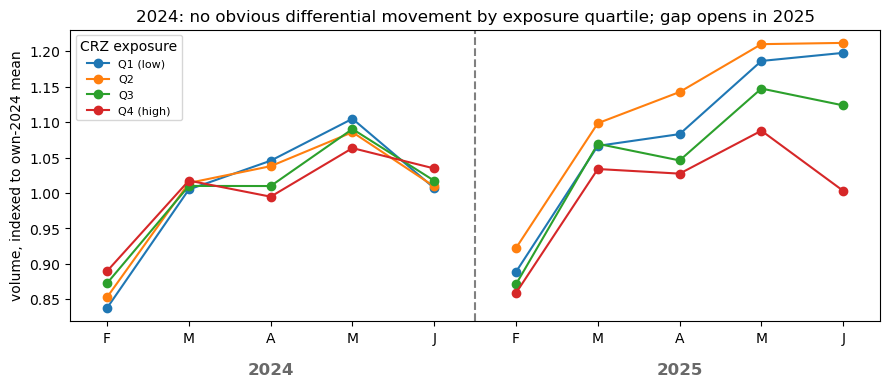

In [6]:
# Pre-trend: index each zone×direction to its own 2024 mean, average by 2024-exposure quartile.
# NB: indexing to each unit's own 2024 mean mechanically pins the 2024 level ~1, so this is a
# weak seasonality check (no obvious differential movement), NOT a full parallel-trends test.
base = mp[mp.year == 2024].groupby("zone_dir").n_trips.mean().rename("b24")
mp = mp.merge(base, on="zone_dir"); mp["idx"] = mp.n_trips / mp.b24
q = mp.drop_duplicates("zone_dir")[["zone_dir", "charged_share"]].copy()
q["exp_q"] = pd.qcut(q.charged_share, 4, labels=["Q1 (low)", "Q2", "Q3", "Q4 (high)"])
mp = mp.merge(q[["zone_dir", "exp_q"]], on="zone_dir")

import matplotlib.pyplot as plt
traj = mp.groupby(["exp_q", "year", "month"], observed=True).idx.mean().reset_index()
traj["t"] = (traj.year - 2024) * 5 + (traj.month - 2)                 # 0..9 time axis
fig, ax = plt.subplots(figsize=(9, 4))
colors = plt.cm.tab10.colors
for i, (name, g) in enumerate(traj.groupby("exp_q", observed=True)):
    g = g.sort_values("t")
    for yr in (2024, 2025):                                    # break the line across the year gap
        gy = g[g.year == yr]
        ax.plot(gy.t, gy.idx, marker="o", color=colors[i],
                label=str(name) if yr == 2024 else None)
ax.axvline(4.5, ls="--", c="grey")
for xc, yr in [(2, "2024"), (7, "2025")]:                       # label each half clearly
    ax.text(xc, -0.14, yr, ha="center", va="top", transform=ax.get_xaxis_transform(),
            fontsize=12, weight="bold", color="dimgrey")
ax.set_xticks(range(10)); ax.set_xticklabels(list("FMAMJ") * 2)
ax.set_xlabel(""); ax.set_ylabel("volume, indexed to own-2024 mean")
ax.set_title("2024: no obvious differential movement by exposure quartile; gap opens in 2025")
ax.legend(title="CRZ exposure", fontsize=8); plt.tight_layout(); plt.show()

In [7]:
# DiD estimates (cluster-by-zone SE). Reported: the gradient/contrast term and the share=0 reference.
def did(df, term):
    m = smf.ols(f"log_n ~ C(zone_dir) + C(month) + post + post:{term}", df).fit(
        cov_type="cluster", cov_kwds={"groups": df.zone})
    b = m.params[f"post:{term}"]; lo, hi = m.conf_int().loc[f"post:{term}"]
    return b, lo, hi, m.params["post"]

print(f"{'spec':<32}{'post×term':>10}{'  95% CI':>20}{'  →%':>8}{'  ref(post,share0)':>18}")
for name, df, term in [
    ("dose-response (charged_share)",  mp,                        "charged_share"),
    ("binary CRZ (contaminated ctrl)", mp,                        "crz_int"),
    ("within-Manhattan (binary CRZ)",  mp[mp.Borough=="Manhattan"], "crz_int"),
    ("within-Manhattan (dose)",        mp[mp.Borough=="Manhattan"], "charged_share"),
]:
    b, lo, hi, p0 = did(df, term)
    print(f"{name:<32}{b:+8.4f}  [{lo:+.4f},{hi:+.4f}]{(np.exp(b)-1)*100:+7.1f}%{(np.exp(p0)-1)*100:+15.1f}%")

spec                             post×term              95% CI      →%  ref(post,share0)


dose-response (charged_share)    -0.1004  [-0.1313,-0.0694]   -9.5%           +9.1%


binary CRZ (contaminated ctrl)   -0.0661  [-0.0877,-0.0446]   -6.4%           +6.3%
within-Manhattan (binary CRZ)    +0.0183  [-0.0061,+0.0426]   +1.8%           -2.3%
within-Manhattan (dose)          +0.0194  [-0.0172,+0.0561]   +2.0%           -2.6%


In [8]:
# Robustness — two distinct checks.
# (1) Trimming thin zone-sides: only cutoffs dropping <=10% of units are reported, so the trim
#     cannot distort the sample. (Extreme cutoffs, e.g. min_n>=1000, remove 60-70% of units and
#     collapse the panel to a mostly-Manhattan, high-exposure subsample in which the exposure
#     gradient is no longer identified — estimates there are not interpretable.)
# (2) Weighting: equal-weight OLS (each zone-side one vote) vs WLS by 2024 volume (each trip,
#     approximately, one vote). This is an estimand choice, not a technical fix.
def _grad(min_n, wls=False):
    d = pd.read_csv(DS / "yellow_monthly_panel.csv"); d = d[d.charged_share.notna()].copy()
    cc = d.groupby(["zone", "direction"]).size()
    d = d.set_index(["zone", "direction"]).loc[cc[cc == 10].index].reset_index()
    d = d[d.groupby(["zone", "direction"]).n_trips.transform("min") >= min_n].copy()
    d["zone_dir"] = d.zone.astype(str) + "_" + d.direction
    d["post"] = (d.year == 2025).astype(int); d["log_n"] = np.log(d.n_trips)
    d = d.merge(d[d.year == 2024].groupby("zone_dir").n_trips.mean().rename("b24"), on="zone_dir")
    f = "log_n ~ C(zone_dir) + C(month) + post + post:charged_share"
    m = (smf.wls(f, d, weights=d.b24) if wls else smf.ols(f, d)).fit(
        cov_type="cluster", cov_kwds={"groups": d.zone})
    b = m.params["post:charged_share"]; lo, hi = m.conf_int().loc["post:charged_share"]
    return d.zone_dir.nunique(), b, lo, hi

n_base = _grad(30)[0]
print("thin-unit trim (equal-weight OLS; cutoffs limited to <=10% of units dropped):")
print(f"{'min_n':>6}{'units':>7}{'dropped':>9}{'gradient':>10}{'  ->%':>8}{'  95% CI':>20}")
for mn in [30, 40, 50, 60, 75]:
    u, b, lo, hi = _grad(mn)
    print(f"{mn:>6}{u:>7}{1 - u/n_base:>9.1%}{b:>10.4f}{(np.exp(b)-1)*100:+7.1f}%  [{lo:+.4f},{hi:+.4f}]")

u, b, lo, hi = _grad(30, wls=True)
print(f"\nWLS by 2024 volume (min_n=30): {b:+.4f} [{lo:+.4f},{hi:+.4f}]"
      f" -> {(np.exp(b)-1)*100:+.1f}%  (CI incl. 0)")
print("=> equal-weighted gradient is stable to non-distorting trims (~-9.5%). The 2024-volume-weighted"
      "\n   estimate is near zero and statistically indistinguishable from 0, so the negative gradient"
      "\n   appears to be a per-zone-side pattern, not a trip-weighted volume effect. (WLS approximates"
      "\n   the average-trip estimand; it is not a trip-level causal model -> 'no evidence of a negative"
      "\n   effect', not proof of no effect.)")

thin-unit trim (equal-weight OLS; cutoffs limited to <=10% of units dropped):
 min_n  units  dropped  gradient     ->%              95% CI


    30    460     0.0%   -0.1004   -9.5%  [-0.1313,-0.0694]


    40    447     2.8%   -0.1019   -9.7%  [-0.1319,-0.0719]


    50    440     4.3%   -0.1016   -9.7%  [-0.1320,-0.0712]


    60    429     6.7%   -0.0996   -9.5%  [-0.1304,-0.0689]


    75    419     8.9%   -0.1005   -9.6%  [-0.1315,-0.0694]



WLS by 2024 volume (min_n=30): +0.0154 [-0.0208,+0.0515] -> +1.5%  (CI incl. 0)
=> equal-weighted gradient is stable to non-distorting trims (~-9.5%). The 2024-volume-weighted
   estimate is near zero and statistically indistinguishable from 0, so the negative gradient
   appears to be a per-zone-side pattern, not a trip-weighted volume effect. (WLS approximates
   the average-trip estimand; it is not a trip-level causal model -> 'no evidence of a negative
   effect', not proof of no effect.)


**Model 2 finding — a statistically clear equal-weighted gradient that does not survive volume weighting; the trip-weighted estimate shows no evidence of a negative effect.**

- **Dose-response (equal-weighted zone-sides):** a fully-exposed zone-side lost ≈ **−9.5%** more than a
  zero-exposure one (CI [−13.1%, −6.9%]); zero-exposure zones grew +9.1%. This is **stable to trimming
  thin zone-sides** within a non-distorting range (cutoffs dropping ≤10% of units: −9.5% to −9.7%) — it
  is not an artifact of a few noisy thin units. (Extreme cutoffs are not evidence either way: dropping
  60–70% of units collapses the panel to a mostly-Manhattan, high-exposure subsample where the
  gradient is no longer identified.)
- **But it does not survive the weighting choice, and the weighting choice is the estimand:**
  weighting by 2024 volume (≈ each *trip* a vote instead of each *zone-side*) gives **+1.5%, CI incl. 0**.
  The negative gradient is carried by the many low-volume zone-sides; the high-volume zone-sides that
  carry most trips show no drop. So Model 2's per-**zone-side** gradient is ≈ −9.5%, while the
  2024-volume-weighted estimate (approximating a per-**trip** view) is near zero and indistinguishable
  from 0 — **no evidence of a negative effect**. WLS only *approximates* the average-trip estimand (it
  is not a trip-level causal model), so this is absence of a detectable effect, not a proven null.
- **Within Manhattan is _inconclusive_, not confirmatory.** Restricting to Manhattan (CRZ south of
  60th St, exposure ≈ 1, vs Upper Manhattan north of 60th, exposure ≈ 0.1–0.5) gives +1.8% binary /
  +2.0% dose (both CI incl. 0). This does **not** show the effect was confound: the contrast is still
  *geographic* (downtown vs uptown → differential non-fee trends remain possible), and the 'control'
  (Upper Manhattan) is itself 10–50% exposed — a **partially-treated control** that attenuates any true
  effect toward zero. So it neither confirms nor refutes the effect. (No geography-based split escapes
  this, because treatment ≈ geography — the reason we need Model 3.) *For the within-Manhattan rows the
  `ref(post,share0)` column is an extrapolation — Manhattan has no zero-exposure zone.*
- **Pre-trends:** the 2024 within-window plot (equal-weighted zone-sides, matching the OLS estimand)
  shows *no obvious differential movement by exposure quartile* — but with only 5 pre-months, and each unit indexed to its own 2024 mean (which
  mechanically pins the 2024 level), this is a **weak seasonality check, not a full parallel-trends
  test**. A 2023 placebo would strengthen it (deferred; not a blocker).

**Bottom line:** for yellow, Model 2 finds a **−9.5% per-zone-side** exposure gradient that is stable to
non-distorting trims, but the **2024-volume-weighted estimate is near zero and statistically
indistinguishable from zero** — so the negative gradient appears to be a per-**zone-side** pattern, not a
trip-weighted volume effect; the trip-weighted view shows **no evidence of a negative effect**. The
within-Manhattan check is inconclusive. Consistent with a small $0.75 fee. **Model 3** (same-zone yellow
vs HVFHV) is the clean test.

## Summary
- **Model 1** (cross-zone `DS_z`<->volume): weak (~ -0.16) and **not identified** — at the zone level
  "charged", "dense", and "high `DS_z`" are nearly the same object, so the coefficient swings with
  the spec (+0.72 to -3.83). Gives the burden **ranking** (Goal 1), not a volume effect (Goal 2).
- **Model 2** (geographic exposure-gradient DiD): a **−9.5% per-zone-side** gradient (stable to
  non-distorting trims); the **2024-volume-weighted estimate is near zero (ns)**, so the drop is a
  per-zone-side pattern and the **trip-weighted view shows no evidence of a negative effect** (the
  within-Manhattan check is inconclusive — a still-geographic contrast with a partially-treated
  control). Consistent with the small $0.75 fee.
- **Net for yellow:** no robust evidence that the fee reduced volume; the honest deliverable is the
  burden ranking (Goal 1) plus a well-characterized null/fragile volume effect (Goal 2).
